In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torchvision.models as models

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from IPython.display import clear_output
from tqdm import tqdm

## Setup & Device

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("output", exist_ok=True)

## Data Collection

In [5]:
label_map = {
    "glaucoma": 1, "Glaucoma": 1, "GLAUCOMA": 1,
    "normal": 0, "Normal": 0, "NORMAL": 0,
    "Non Glaucoma": 0
}

In [6]:
def collect_image_paths(root_dir):
    image_paths, labels = [], []
    for subdir, _, files in os.walk(root_dir):
        for fn in files:
            if fn.lower().endswith(('.png','.jpg','.jpeg')):
                class_name = os.path.basename(os.path.normpath(subdir))
                if class_name in label_map:
                    image_paths.append(os.path.join(subdir,fn))
                    labels.append(label_map[class_name])
    return image_paths, labels

## ROI Extraction & Enhancement

In [7]:
def extract_roi_and_enhance(image_path, target_size=(224, 224), show_steps=False, i=0):
    img = cv2.imread(image_path)
    img_name_ext = os.path.basename(image_path)
    img_name = os.path.splitext(img_name_ext)[0]
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return np.zeros((224, 224, 3), np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    blurred = cv2.GaussianBlur(gray, (15, 15), 0)
    
    _, _, _, maxLoc = cv2.minMaxLoc(blurred)
    x, y = maxLoc

    crop = 300
    x1, y1 = max(0, x - crop), max(0, y - crop)
    x2, y2 = min(img.shape[1], x + crop), min(img.shape[0], y + crop)
    roi = img[y1:y2, x1:x2]

    lab = cv2.cvtColor(roi, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl, a, b))
    
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    resized = cv2.resize(enhanced, target_size)
    
    final_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

    if show_steps:
        clear_output(wait=True)
        plt.figure(figsize=(15, 8))
        
        plt.subplot(2, 3, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("1. Original Image")
        plt.axis("off")
        
        plt.subplot(2, 3, 2)
        plt.imshow(gray, cmap='gray')
        plt.title("2. Grayscale")
        plt.axis("off")
        
        plt.subplot(2, 3, 3)
        plt.imshow(blurred, cmap='gray')
        plt.plot(x, y, 'ro', markersize=8)
        plt.title("3. Blurred (Red dot = MaxLoc)")
        plt.axis("off")
        
        plt.subplot(2, 3, 4)
        plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        plt.title("4. Cropped ROI")
        plt.axis("off")
        
        plt.subplot(2, 3, 5)
        plt.imshow(cl, cmap='gray')
        plt.title("5. CLAHE on L-Channel")
        plt.axis("off")
        
        plt.subplot(2, 3, 6)
        plt.imshow(final_rgb)
        plt.title("6. Final Enhanced & Resized")
        plt.axis("off")
        
        plt.tight_layout()
        plt.savefig(f"feature-extraction/{img_name}fe.png", dpi=150)
        plt.show()

    return final_rgb

## Dataset Class & Dataloaders

In [8]:
class GlaucomaDataset(Dataset):
    def __init__(self, paths, labels, is_train=False, show_steps=False):
        self.paths = paths
        self.labels = labels
        self.show_steps = show_steps
        self.is_train = is_train
        
        if self.is_train:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
            ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = extract_roi_and_enhance(self.paths[idx], show_steps=self.show_steps)
        img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

### Load Datasets

In [9]:
paths1, labs1 = collect_image_paths("datasets/ACRIMA")
paths2, labs2 = collect_image_paths("datasets/RIM-ONE")
paths3, labs3 = collect_image_paths("datasets/Drishti-GS1")

all_paths = paths1 + paths2 + paths3
all_labels = labs1 + labs2 + labs3

train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.15, stratify=train_labels, random_state=42
)

In [23]:
class_counts = np.bincount(train_labels)
weights = [1.0/class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(
    GlaucomaDataset(train_paths, train_labels),
    batch_size=32, sampler=sampler
)

val_loader = DataLoader(
    GlaucomaDataset(val_paths, val_labels),
    batch_size=32, shuffle=False
)

test_loader = DataLoader(
    GlaucomaDataset(test_paths, test_labels, show_steps=True),
    batch_size=32, shuffle=False
)

## End-to-End ANFIS & MultiNet CNN

In [11]:
class ANFIS(nn.Module):
    def __init__(self, input_dim, num_rules):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_rules, input_dim))
        self.sigmas = nn.Parameter(torch.ones(num_rules, input_dim))
        self.coeff = nn.Parameter(torch.randn(num_rules, input_dim))
        self.bias = nn.Parameter(torch.randn(num_rules, 1))

    def forward(self, x):
        x_exp = x.unsqueeze(1)
        mu = torch.exp(-((x_exp - self.centers)**2) / (2 * (self.sigmas**2) + 1e-6))
        w = torch.prod(mu, dim=2)
        w_norm = w / (torch.sum(w, dim=1, keepdim=True) + 1e-6)
        f = torch.matmul(x, self.coeff.t()) + self.bias.squeeze()
        out = torch.sum(w_norm * f, dim=1)
        return out.unsqueeze(1)

In [12]:
class ANFISCNN(nn.Module):
    def __init__(self, num_rules=8, anfis_dim=16):
        super().__init__()
        self.resnet = models.resnet50(weights="DEFAULT")
        self.densenet = models.densenet121(weights="DEFAULT")
        self.mobilenet = models.mobilenet_v2(weights="DEFAULT")

        rf = self.resnet.fc.in_features
        df = self.densenet.classifier.in_features
        mf = self.mobilenet.classifier[1].in_features

        self.resnet.fc = nn.Identity()
        self.densenet.classifier = nn.Identity()
        self.mobilenet.classifier = nn.Identity()

        self.feature_reduction = nn.Sequential(
            nn.Linear(rf + df + mf, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, anfis_dim),
            nn.BatchNorm1d(anfis_dim), 
            nn.Tanh() 
        )

        self.anfis = ANFIS(input_dim=anfis_dim, num_rules=num_rules)

    def forward(self, x, return_features=False):
        f1 = self.resnet(x)
        f2 = self.densenet(x)
        f3 = self.mobilenet(x)
        fused = torch.cat([f1, f2, f3], dim=1)

        reduced_features = self.feature_reduction(fused)
        
        if return_features:
            return reduced_features
            
        return self.anfis(reduced_features)

## Training Routine

In [13]:
def train_model(model, train_loader, val_loader, epochs=15):
    optimizer = optim.Adam([
        {'params': model.resnet.parameters(), 'lr': 1e-5},
        {'params': model.densenet.parameters(), 'lr': 1e-5},
        {'params': model.mobilenet.parameters(), 'lr': 1e-5},
        {'params': model.feature_reduction.parameters(), 'lr': 1e-3},
        {'params': model.anfis.parameters(), 'lr': 1e-3}
    ])
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    
    criterion = nn.BCEWithLogitsLoss()
    best_auc = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            progress_bar.set_postfix({'loss': loss.item()})

        model.eval()
        scores, labs = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                logits = model(images)
                probs = torch.sigmoid(logits)
                scores += probs.cpu().numpy().flatten().tolist()
                labs += labels.numpy().tolist()

        auc_val = roc_auc_score(labs, scores)
        scheduler.step(auc_val)

        if auc_val > best_auc:
            best_auc = auc_val
            torch.save(model.state_dict(), "best_model.pth")

        avg_train_loss = train_loss / len(train_loader)
        
        print(f"End of Epoch {epoch+1} | Val AUC: {auc_val:.3f} | Train Loss: {avg_train_loss:.4f}\n")

    return best_auc

### Initialize and Train

In [14]:
print("Initializing End-to-End Model...")
cnn_anfis_model = ANFISCNN(num_rules=8, anfis_dim=16).to(device)

print("Starting Training...")
train_model(cnn_anfis_model, train_loader, val_loader, epochs=5)

Initializing End-to-End Model...
Starting Training...


Epoch 1/5: 100%|██████████████████████████████████████████████████████████| 38/38 [08:54<00:00, 14.06s/it, loss=0.0947]


End of Epoch 1 | Val AUC: 0.952 | Train Loss: 0.3885



Epoch 2/5: 100%|█████████████████████████████████████████████████████████████| 38/38 [08:43<00:00, 13.77s/it, loss=0.1]


End of Epoch 2 | Val AUC: 0.980 | Train Loss: 0.1536



...

Epoch 4/5: 100%|██████████████████████████████████████████████████████████| 38/38 [10:23<00:00, 16.41s/it, loss=0.0227]


End of Epoch 4 | Val AUC: 0.990 | Train Loss: 0.0564



Epoch 5/5: 100%|██████████████████████████████████████████████████████████| 38/38 [10:26<00:00, 16.50s/it, loss=0.0484]


End of Epoch 5 | Val AUC: 0.990 | Train Loss: 0.0419



0.9902239601848561

## Final Test Evaluation & Baseline Comparison

In [15]:
results = {}
model_results = {}

def evaluate_model(model, loader):
    model.eval()
    scores, labels_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits)

            scores.extend(probs.cpu().numpy().flatten())
            labels_all.extend(labels.numpy().flatten())

    auc_val = roc_auc_score(labels_all, scores)
    preds = (np.array(scores) >= 0.5).astype(int)

    acc = accuracy_score(labels_all, preds)
    tn, fp, fn, tp = confusion_matrix(labels_all, preds).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return auc_val, acc, sensitivity, specificity, labels_all, scores

def get_model(name):
    if name == "resnet18":
        model = models.resnet18(weights="DEFAULT") 
        model.fc = nn.Linear(model.fc.in_features,1)
    elif name == "densenet121":
        model = models.densenet121(weights="DEFAULT")
        model.classifier = nn.Linear(model.classifier.in_features,1)
    elif name == "mobilenet":
        model = models.mobilenet_v2(weights="DEFAULT")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features,1)
    elif name == "MultiNet_ANFIS":
        model = ANFISCNN(num_rules=8, anfis_dim=16)
        model.load_state_dict(torch.load("best_model.pth", map_location=device))
        
    return model.to(device)

In [ ]:
print("\nEvaluating Models on Test Set...")
model_names = ["resnet18", "densenet121", "mobilenet", "MultiNet_ANFIS"]

for name in model_names:
    print(f"Evaluating {name}...")
    model = get_model(name)
    auc_val, acc, sens, spec, labs, scores = evaluate_model(model, test_loader)

    results[name] = {
        "AUC": auc_val,
        "Accuracy": acc,
        "Sensitivity": sens,
        "Specificity": spec
    }

    # print(f"{name} -> {results[name]}")
    model_results[name] = (labs, scores)

results

## Visualizations

### ROC Curve

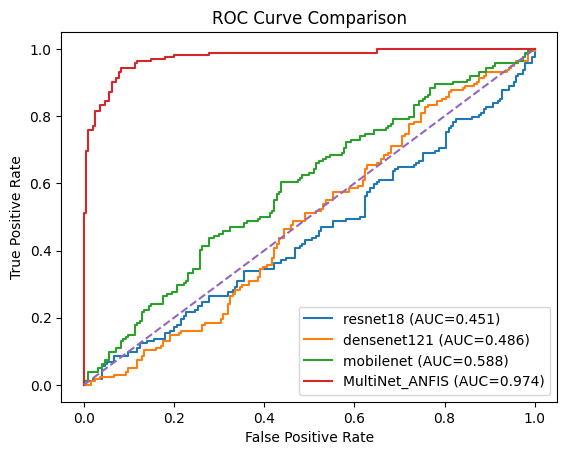

In [29]:
plt.figure()
for name, (labels, scores) in model_results.items():
    fpr, tpr, _ = roc_curve(labels, scores)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("output/roc_comparison.png", dpi=300)
plt.show()
plt.close()

### PR Curve

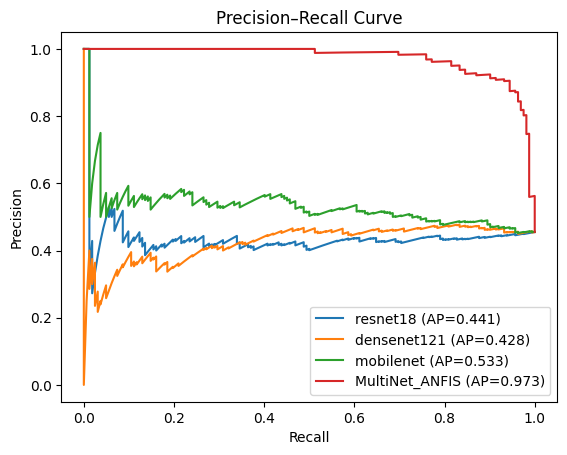

In [28]:
plt.figure()
for name, (labels, scores) in model_results.items():
    precision, recall, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.savefig("output/pr_curve.png", dpi=300)
plt.show()
plt.close()

### Confusion Matrix

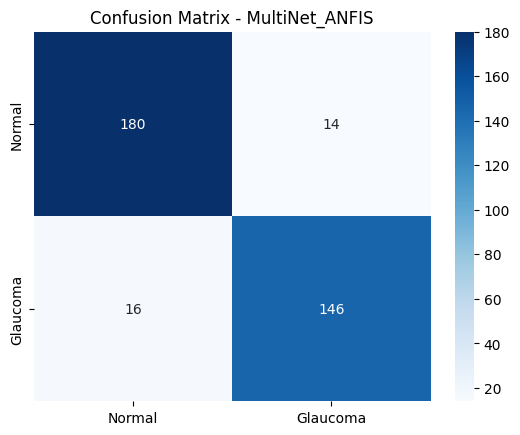

In [27]:
best_model = "MultiNet_ANFIS"
labels, scores = model_results[best_model]
preds = (np.array(scores) >= 0.5).astype(int)
cm = confusion_matrix(labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Glaucoma"],
            yticklabels=["Normal","Glaucoma"])
plt.title(f"Confusion Matrix - {best_model}")
plt.savefig("output/confusion_matrix.png", dpi=300)
plt.show()
plt.close()

### Grouped Performance Chart

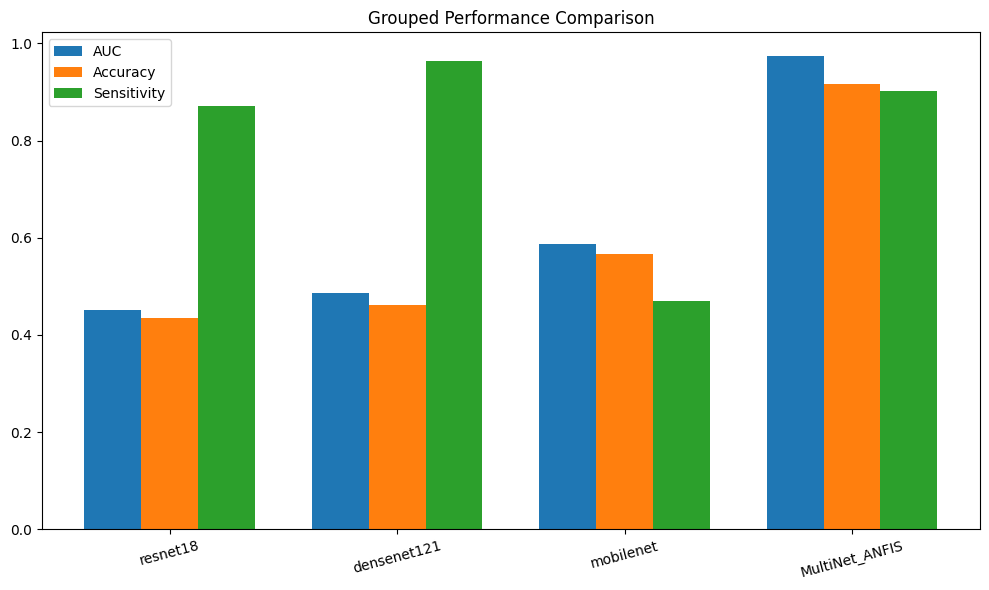

In [30]:
models_list = list(results.keys())
aucs = [results[m]["AUC"] for m in models_list]
accs = [results[m]["Accuracy"] for m in models_list]
sens = [results[m]["Sensitivity"] for m in models_list]

x = np.arange(len(models_list))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, aucs, width, label="AUC")
plt.bar(x, accs, width, label="Accuracy")
plt.bar(x + width, sens, width, label="Sensitivity")

plt.xticks(x, models_list, rotation=15)
plt.legend()
plt.title("Grouped Performance Comparison")
plt.tight_layout()
plt.savefig("output/grouped_bar.png", dpi=300)
plt.show()
plt.close()

### Radar Chart

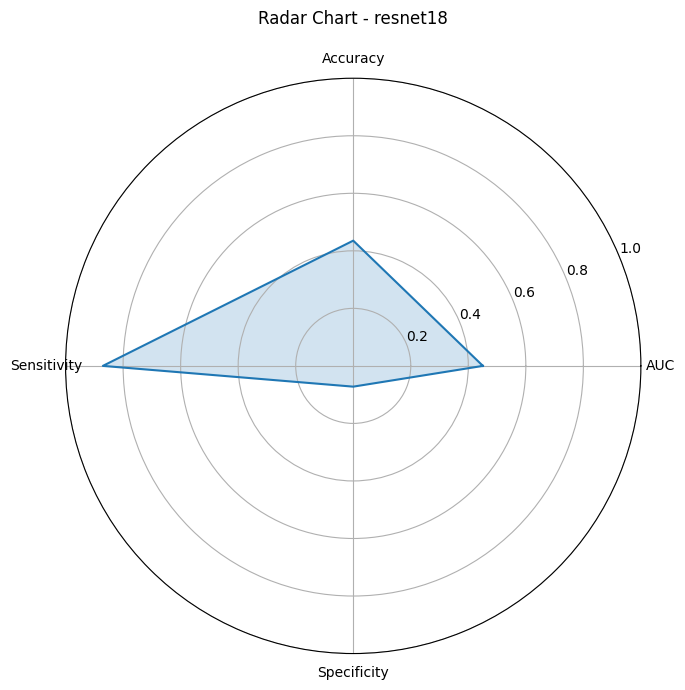

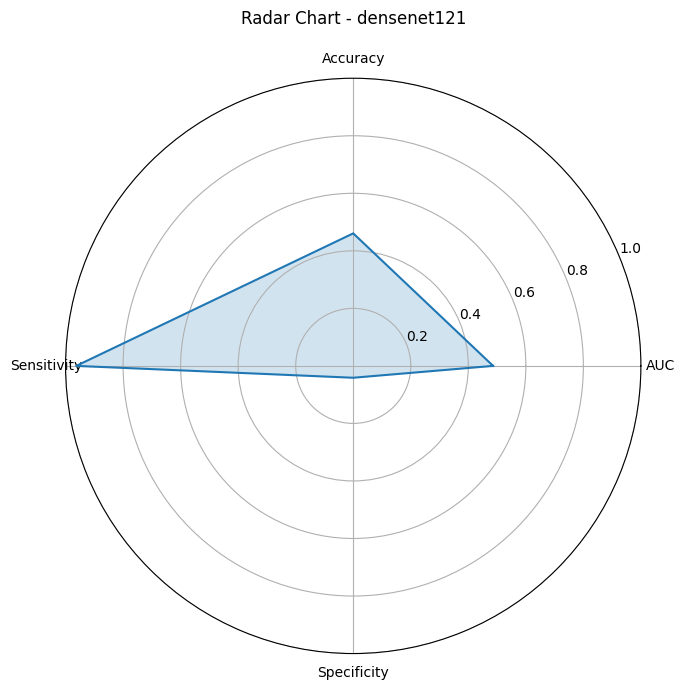

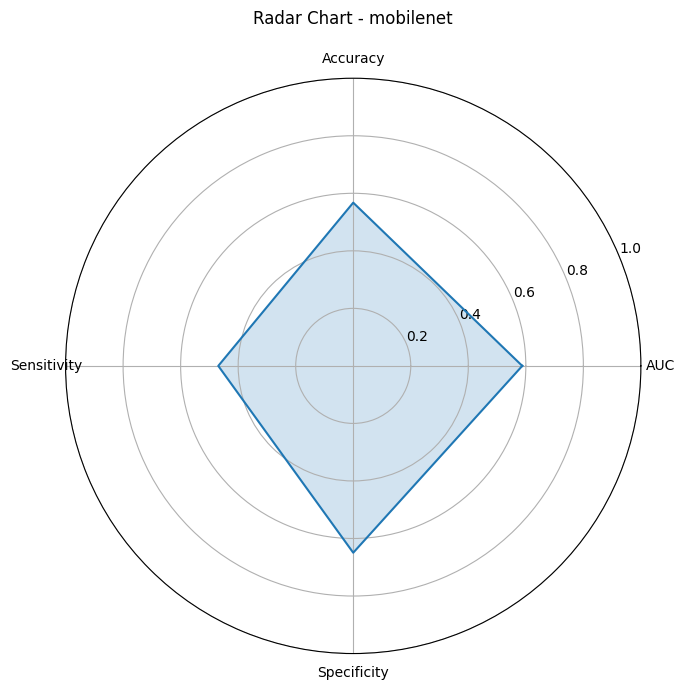

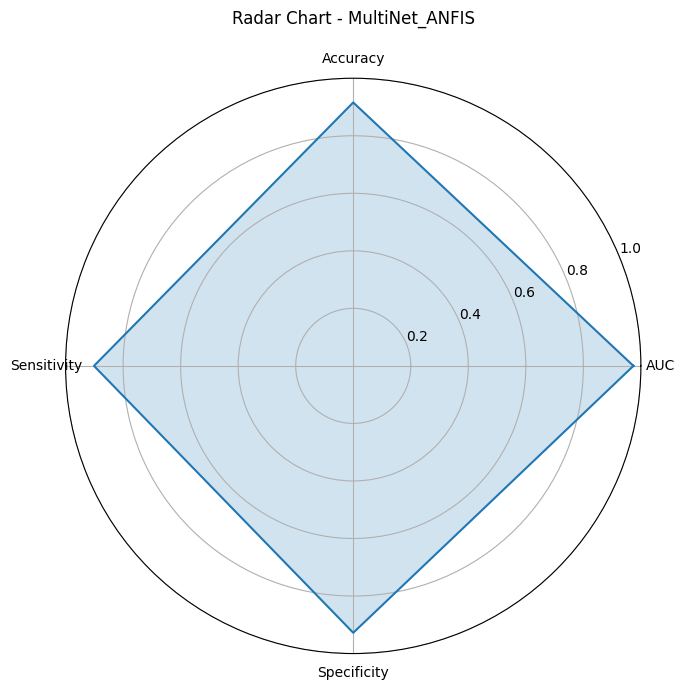

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

models_list = list(results.keys())
metrics = ["AUC", "Accuracy", "Sensitivity", "Specificity"]

num_vars = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close loop

os.makedirs("output", exist_ok=True)

for model in models_list:
    values = [results[model][metric] for metric in metrics]
    values += values[:1]

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1)

    plt.title(f"Radar Chart - {model}", pad=20)
    plt.tight_layout()
    plt.savefig(f"output/radar_{model}.png", dpi=300)
    plt.show()
    plt.close()

## Random Test Image Visualization

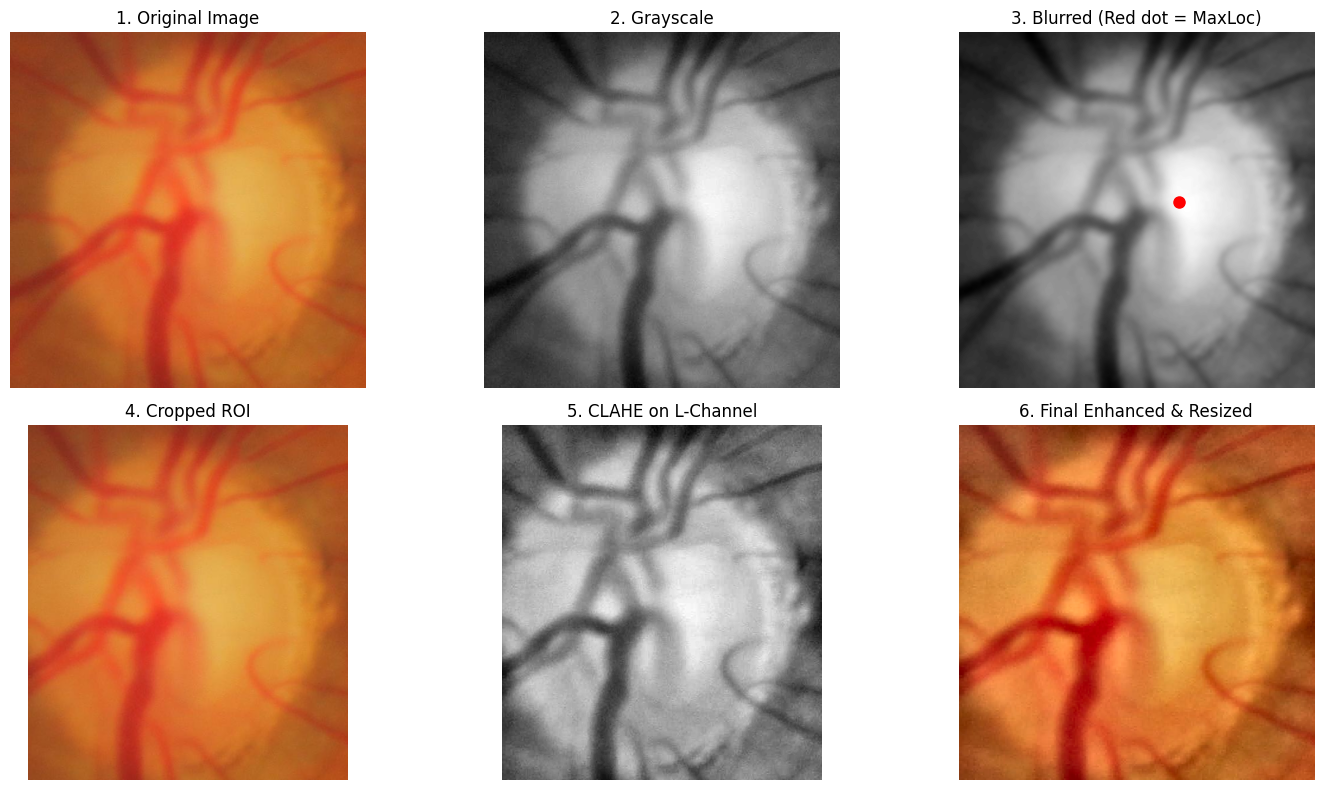

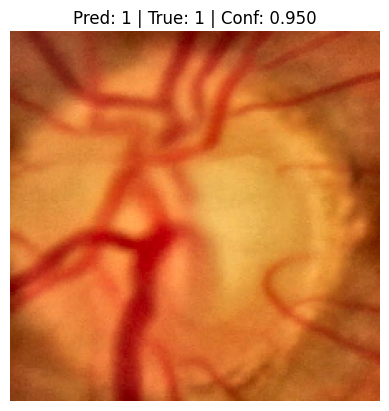

In [32]:
idx = random.randint(0, len(test_loader.dataset)-1)
img_tensor, true_label = test_loader.dataset[idx]
input_tensor = img_tensor.unsqueeze(0).to(device)

best_model_obj = get_model(best_model)
best_model_obj.eval()

with torch.no_grad():
    logits = best_model_obj(input_tensor)
    prob = torch.sigmoid(logits).item()
    pred = 1 if prob >= 0.5 else 0

img_np = img_tensor.permute(1,2,0).numpy()
mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

plt.figure()
plt.imshow(img_np)
plt.title(f"Pred: {pred} | True: {int(true_label)} | Conf: {prob:.3f}")
plt.axis("off")
plt.savefig("output/test_prediction.png", dpi=300)
plt.show()
plt.close()